<a href="https://colab.research.google.com/github/npoctobodya/gosportal/blob/main/chapter_appendix-tools-for-deep-learning/jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.18.0


In [11]:
# Загрузка датасета MNIST
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Нормализация данных (приведение значений пикселей к диапазону 0-1)
x_train, x_test = x_train / 255.0, x_test / 255.0

# Вывод информации о датасете
print("Форма тренировочных данных:", x_train.shape)
print("Форма тестовых данных:", x_test.shape)
print("Количество классов:", len(set(y_train)))

Форма тренировочных данных: (60000, 28, 28)
Форма тестовых данных: (10000, 28, 28)
Количество классов: 10


In [12]:
# Создание модели последовательного типа
model = tf.keras.models.Sequential([
    # Преобразование изображения 28x28 в вектор из 784 элементов
    tf.keras.layers.Flatten(input_shape=(28, 28)),

    # Полносвязный слой с 128 нейронами и функцией активации ReLU
    tf.keras.layers.Dense(128, activation='relu'),

    # Dropout для регуляризации (отключает 20% нейронов случайным образом)
    tf.keras.layers.Dropout(0.2),

    # Выходной слой с 10 нейронами (по количеству классов) и функцией активации softmax
    tf.keras.layers.Dense(10, activation='softmax')
])

# Компиляция модели
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Вывод структуры модели
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8475 - loss: 0.5248 - val_accuracy: 0.9563 - val_loss: 0.1565
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9485 - loss: 0.1687 - val_accuracy: 0.9660 - val_loss: 0.1129
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9627 - loss: 0.1197 - val_accuracy: 0.9691 - val_loss: 0.1008
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9726 - loss: 0.0930 - val_accuracy: 0.9710 - val_loss: 0.0927
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9750 - loss: 0.0800 - val_accuracy: 0.9731 - val_loss: 0.0911
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9777 - loss: 0.0707 - val_accuracy: 0.9766 - val_loss: 0.0807
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9824 - loss: 0.0568 - val_accuracy: 0.9766 - val_loss: 0.0841
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9841 - loss: 0.0488 

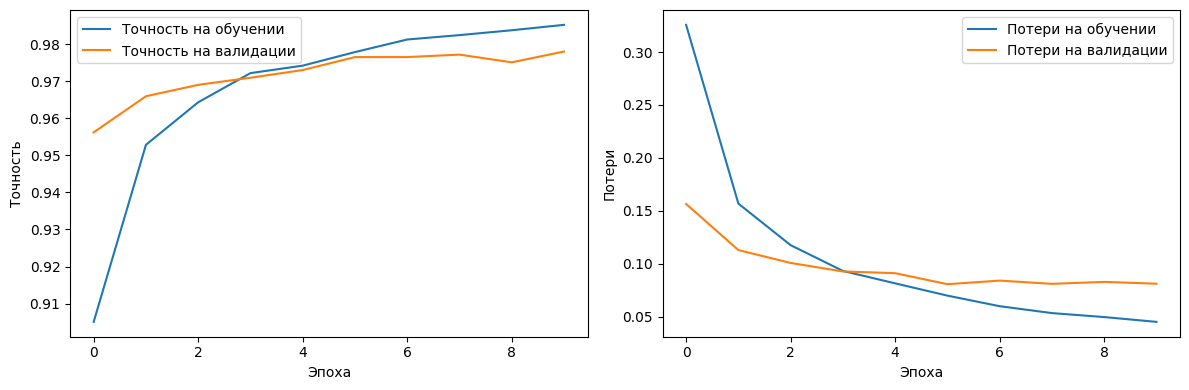

In [13]:
# Обучение модели
history = model.fit(x_train, y_train,
                    epochs=10,
                    validation_split=0.2)

# Визуализация процесса обучения
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# График точности
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Точность на обучении')
plt.plot(history.history['val_accuracy'], label='Точность на валидации')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()

# График потерь
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Потери на обучении')
plt.plot(history.history['val_loss'], label='Потери на валидации')
plt.xlabel('Эпоха')
plt.ylabel('Потери')
plt.legend()

plt.tight_layout()
plt.show()

In [43]:
# Оценка модели на тестовых данных
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nТочность на тестовых данных: {test_acc:.4f}")

# Пример предсказания для нескольких изображений
predictions = model.predict(x_test[:50])
predicted_labels = tf.argmax(predictions, axis=1)

# Визуализация примеров с предсказаниями
plt.figure(figsize=(100, 100))
for i in range(50):
    plt.subplot(5, 10, i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Предсказано: {predicted_labels[i]}\nФактически: {y_test[i]}", fontdict={'fontsize': 58})
    plt.axis('off')
plt.tight_layout()
plt.show()

313/313 - 1s - 2ms/step - accuracy: 0.9779 - loss: 0.0702

Точность на тестовых данных: 0.9779
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
